In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.turbulence_dataset import TurbulenceDataset
from turbpred.v2d_transformations import Transforms
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion
from turbpred.v2d_dataset import V2dDataset
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

device = "cuda:0" if torch.cuda.is_available() else "cpu"

/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
startFromCheckpoint = True
useGPU = True
gpuID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID
pretrainPath = ""

p_d = DataParams(batch=32, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey"], normalizeMode="incMixed")
p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None
if startFromCheckpoint:
    p_t = TrainingParams(epochs=3, lr=0.001)
else:
    p_t = TrainingParams(epochs=3100, lr=0.0001)

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)
model.printModelInfo()

8
in, out 12 84
Weights Trainable (All): 6981300 (6981300)      Dec: 6981300 (6981300)   
PredictionModel(
  (modelDecoder): DiffusionModel(
    (unet): Unet(
      (init_conv): Conv2d(12, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (time_mlp): Sequential(
        (0): SinusoidalPositionEmbeddings()
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): GELU()
        (3): Linear(in_features=512, out_features=512, bias=True)
      )
      (downs): ModuleList(
        (0): ModuleList(
          (0): ConvNextBlock(
            (mlp): Sequential(
              (0): GELU()
              (1): Linear(in_features=512, out_features=84, bias=True)
            )
            (ds_conv): Conv2d(84, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=84)
            (net): Sequential(
              (0): GroupNorm(1, 84, eps=1e-05, affine=True)
              (1): Conv2d(84, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (2): GE

## Inference

In [5]:
testSet = V2dDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/ACDM4SCIENCE/data/v2d",
                     idx_range=[90888, 91488],
                     sequenceLength=[300, 2], rey=1)

testTransformations = Transforms()

testSet.transform = testTransformations

testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)


Loading data from 	 /home/chunyang/projects/ACDM4SCIENCE/data/v2d
Loading completed. Files loaded: 	600
Loading completed. Files loaded: 	1

Dataset info detail:
	 Sequence length of each sample: 300
	 Sequence skiping samples of: 2


In [11]:
print(testSet[0]["data"].shape)

torch.Size([300, 4, 128, 64])


In [14]:
import scipy
import scipy.stats

print(scipy.stats.describe(testSet[0]["data"][:, 0, :, :].flatten()))
print(scipy.stats.describe(testSet[0]["data"][:, 1, :, :].flatten()))
print(scipy.stats.describe(testSet[0]["data"][:, 2, :, :].flatten()))
print(scipy.stats.describe(testSet[0]["data"][:, 3, :, :].flatten()))

DescribeResult(nobs=2457600, minmax=(-27.130756, 2.080064), mean=3.2713375e-05, variance=1.0014774105997357, skewness=-14.642062284426405, kurtosis=289.7319803846848)
DescribeResult(nobs=2457600, minmax=(-30.001518, 13.149414), mean=-0.00049787137, variance=1.0010161896707925, skewness=-5.87720458942715, kurtosis=129.66520539384516)
DescribeResult(nobs=2457600, minmax=(-8.684205, 3.6076539), mean=-0.00079666503, variance=1.0002289312022627, skewness=-3.136186049201659, kurtosis=12.311167034871383)
DescribeResult(nobs=2457600, minmax=(1.0, 1.0), mean=1.0, variance=0.0, skewness=nan, kurtosis=nan)


/tmp/ipykernel_1756921/2242605788.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  print(scipy.stats.describe(testSet[0]["data"][:, 3, :, :].flatten()))
/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1383: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(a, axis, bias=bias)
/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1384: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(a, axis, bias=bias)


In [9]:
# sample for dataset and model inference
if startFromCheckpoint:
    model = PredictionModel.load("/home/chunyang/projects/DDPM4Science/checkpoint/acdm_v2d/Model.pth", useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    print("sampling finished")


Loading model from /home/chunyang/projects/DDPM4Science/runs/2D_Inc/128_acdm-r20_ours_01/Model.pth


/home/chunyang/miniconda3/envs/ai4flow/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


prediction shape before double unsqueeze:  torch.Size([1, 300, 4, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 1, 300, 4, 128, 64])
sampling finished


## Prediction Visualizations

After the sampling, we can analyze the ground truth flow trajectory and the samples generated by ACDM. Let's start with a direct visualization of the predictions.

### Load ground truth sample serial and prediction serial

In [10]:
idx_to_vis = 0

pred = predSamples[0][0, idx_to_vis, :, :, :]
ground = testSet[idx_to_vis]["data"].cpu().numpy()

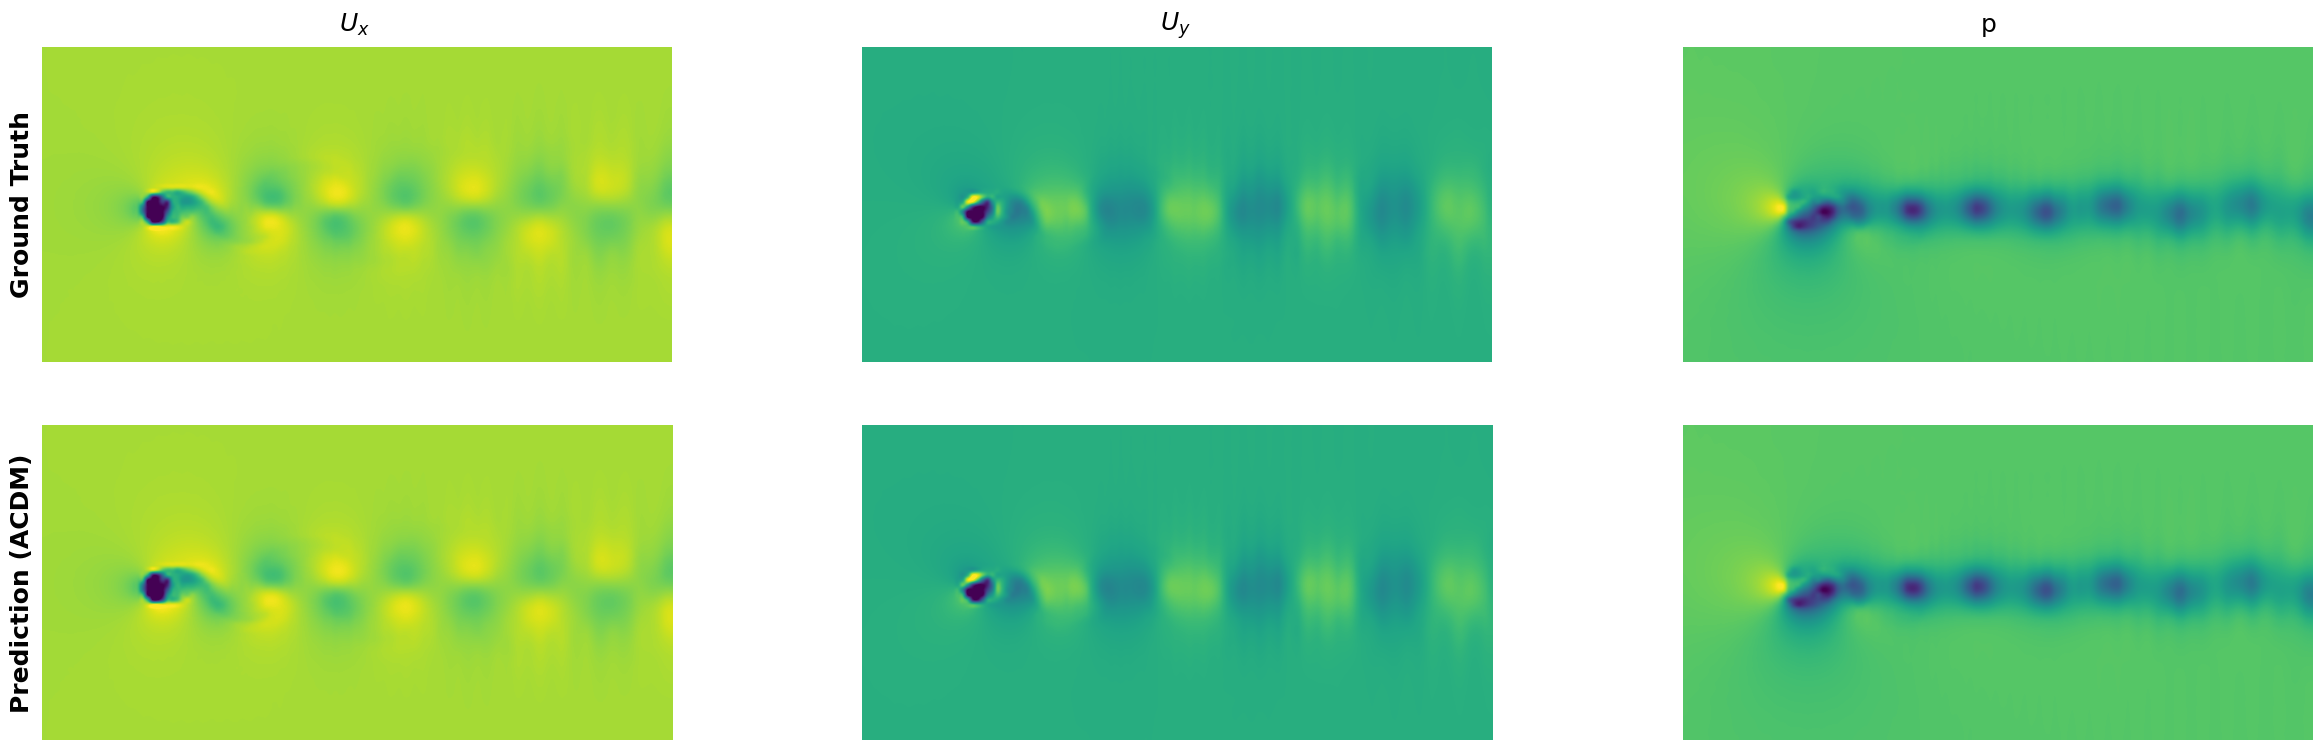

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(30, 9))  # Adjust the figure size as needed

def plot_frame(ground, pred, axs, frame_idx):

    images = []
    for ax in axs.flat:
        ax.clear()
        ax.axis('off')
    i = frame_idx
    # ground_frame
    gf = ground[i, :, :, :]
    ug, vg, pg, _ = gf.clip(-12, 8)
    images.append(axs[0][0].imshow(ug.T, interpolation="catrom"))
    images.append(axs[0][1].imshow(vg.T, interpolation="catrom"))
    images.append(axs[0][2].imshow(pg.T, interpolation="catrom"))
    axs[0][0].text(-0.05, 0.5, 'Ground Truth', va='center', rotation='vertical',
                   transform=axs[0][0].transAxes, fontsize=18, fontweight="bold")
    axs[0][0].text(60, -5, '$U_{x}$', va='center', fontsize=18)
    axs[0][1].text(60, -5, '$U_{y}$', va='center', fontsize=18)
    axs[0][2].text(60, -5, 'p', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf.clip(-12, 8)
    images.append(axs[1][0].imshow(up.T, interpolation="catrom"))
    images.append(axs[1][1].imshow(vp.T, interpolation="catrom"))
    images.append(axs[1][2].imshow(pp.T, interpolation="catrom"))
    axs[1][0].text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=axs[1][0].transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, axs)

plot_frame(ground, pred, axs, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())


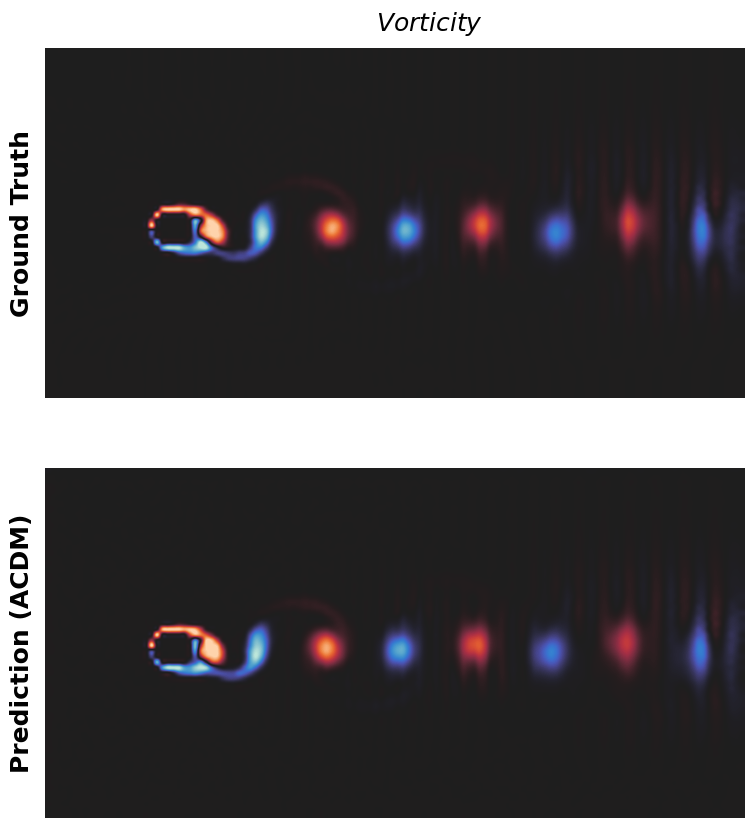

In [19]:
bfig, axs = plt.subplots(2, 1, figsize=(10, 10))  # Adjust the figure size as needed

def plot_frame(ground, pred, axs, frame_idx):
    for ax in axs.flat:
        ax.clear()
        ax.axis('off')
    i = frame_idx
    # ground_frame
    gf = ground[i, :, :, :]
    ug, vg, pg, _ = gf
    vxDx, vxDy = np.gradient(ug)
    vyDx, vyDy = np.gradient(vg)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    axs[0].imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")

    axs[0].text(-0.05, 0.5, 'Ground Truth', va='center', rotation='vertical',
                   transform=axs[0].transAxes, fontsize=18, fontweight="bold")
    axs[0].text(60, -5, '$Vorticity$', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf
    vxDx, vxDy = np.gradient(up)
    vyDx, vyDy = np.gradient(vp)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    axs[1].imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")
    axs[1].text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=axs[1].transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, axs)

plot_frame(ground, pred, axs, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())


In [29]:
import seaborn as sns

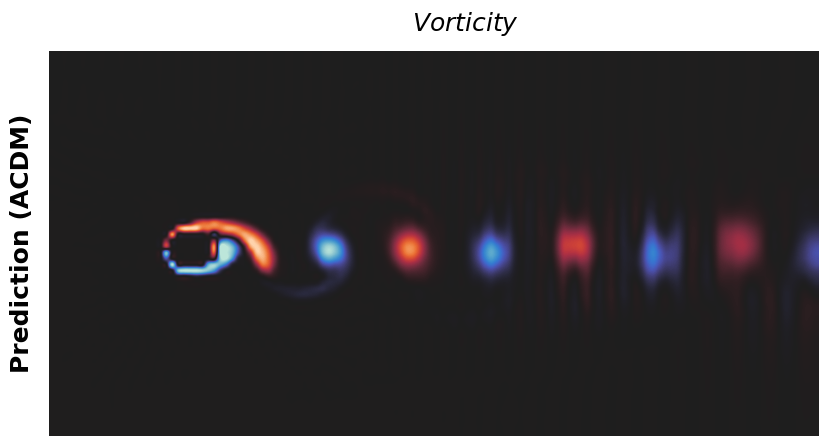

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))  # Adjust the figure size as needed

def plot_frame(ground, pred, ax, frame_idx):
    i = frame_idx
    # print(ax)
    ax.clear()
    ax.axis('off')
    ax.text(60, -5, '$Vorticity$', va='center', fontsize=18)
    # prediction frame
    pf = pred[i, :, :, :]
    up, vp, pp, _ = pf
    vxDx, vxDy = np.gradient(up)
    vyDx, vyDy = np.gradient(vp)
    vort = vyDx - vxDy
    vort = vort.clip(-3, 3)
    ax.imshow(testSet[0]["obsMask"].T * vort.T, interpolation="catrom", cmap="icefire")
    ax.text(-0.05, 0.5, 'Prediction (ACDM)', va='center', rotation='vertical',
                   transform=ax.transAxes, fontsize=18, fontweight="bold")
    return fig

update = partial(plot_frame, ground, pred, ax)

plot_frame(ground, pred, ax, 0)
anim = FuncAnimation(fig, update, frames=300, interval=30)
HTML(anim.to_html5_video())